# Word2Vec (3/3): Con paquetes usuales — spaCy + gensim

En este notebook cerramos el recorrido del Jupyter Book entrenando **Word2Vec con paquetes de uso habitual**.
La idea es pasar de la intuición y la implementación manual a un flujo más cercano a la práctica.

## Objetivos
Al finalizar, podrás:
- Preprocesar texto con **spaCy**.
- Entrenar un modelo **Word2Vec** con **gensim**.
- Consultar vecinos semánticos con `most_similar`.
- Probar analogías vectoriales.
- Visualizar embeddings en 2D con PCA.
- Entender el efecto de hiperparámetros como `vector_size`, `window`, `min_count`, `sg` y `negative`.

> Aquí usamos un corpus pequeño y didáctico para que el notebook sea autocontenido.  
> En un proyecto real, el valor de Word2Vec aparece con corpora mucho más grandes.


## 0. Instalación sugerida

Si te hace falta algún paquete, puedes instalarlo así:

```bash
pip install gensim spacy scikit-learn matplotlib
python -m spacy download es_core_news_sm
```

> Si `es_core_news_sm` no está disponible, el notebook cae en un `spacy.blank("es")` para no romper la ejecución.


In [1]:
from __future__ import annotations

from typing import List, Sequence

import matplotlib.pyplot as plt
import numpy as np
import spacy
from gensim.models import Word2Vec
from sklearn.decomposition import PCA


In [2]:
def load_spacy_model(preferred: str = "es_core_news_sm"):
    try:
        return spacy.load(preferred)
    except Exception:
        lang = preferred.split("_")[0] if "_" in preferred else "es"
        print(
            f"[WARN] Could not load '{preferred}'. Falling back to spacy.blank('{lang}').\n"
            f"       To install the model: python -m spacy download {preferred}"
        )
        return spacy.blank(lang)


nlp = load_spacy_model("es_core_news_sm")


## 1. Corpus base

Usaremos dos estrategias:

1. **Corpus didáctico pequeño**, para ver rápidamente cómo responde el modelo.  
2. Una discusión al final sobre cómo migrar esto a un corpus real.

Con corpora pequeños, las analogías pueden salir bien... o no tanto. Eso también es pedagógicamente útil.


In [3]:
corpus_sentences = [
    "El rey es un hombre.",
    "La reina es una mujer.",
    "El rey gobierna el reino.",
    "La reina gobierna el reino.",
    "El príncipe es un hombre.",
    "La princesa es una mujer.",
    "El príncipe vive en el reino.",
    "La princesa vive en el reino.",
    "El hombre trabaja.",
    "La mujer trabaja.",
    "El rey y la reina viven en el palacio.",
    "El príncipe y la princesa viven en el palacio.",
    "El rey visita el palacio.",
    "La reina visita el palacio.",
    "El príncipe visita el palacio.",
    "La princesa visita el palacio.",
    "El reino tiene un palacio.",
    "La reina cuida el reino.",
    "El rey protege el reino.",
    "La princesa protege el palacio.",
]

print(f"N sentences: {len(corpus_sentences)}")
print("\n".join(corpus_sentences[:6]))


N sentences: 20
El rey es un hombre.
La reina es una mujer.
El rey gobierna el reino.
La reina gobierna el reino.
El príncipe es un hombre.
La princesa es una mujer.


## 2. Preprocesamiento con spaCy

Haremos una limpieza simple:
- minúsculas
- sin espacios ni puntuación
- stopwords opcionales
- lematización opcional

> Para Word2Vec, la decisión entre usar token crudo o lema depende del problema.  
> Si te interesa preservar formas específicas, conviene dejar los tokens tal cual.


In [4]:
def preprocess_sentences(
    sentences: Sequence[str],
    nlp_obj,
    *,
    remove_stop: bool = False,
    use_lemma: bool = False,
    min_token_len: int = 1,
) -> List[List[str]]:
    processed: List[List[str]] = []
    for sentence in sentences:
        doc = nlp_obj(sentence)
        tokens: List[str] = []
        for token in doc:
            if token.is_space or token.is_punct:
                continue
            if remove_stop and token.is_stop:
                continue
            text = token.lemma_.lower().strip() if use_lemma and token.lemma_ else token.text.lower().strip()
            if len(text) < min_token_len:
                continue
            tokens.append(text)
        if tokens:
            processed.append(tokens)
    return processed


tokenized = preprocess_sentences(
    corpus_sentences,
    nlp,
    remove_stop=False,
    use_lemma=False,
    min_token_len=1,
)

tokenized[:5]


[['el', 'rey', 'es', 'un', 'hombre'],
 ['la', 'reina', 'es', 'una', 'mujer'],
 ['el', 'rey', 'gobierna', 'el', 'reino'],
 ['la', 'reina', 'gobierna', 'el', 'reino'],
 ['el', 'príncipe', 'es', 'un', 'hombre']]

## 3. Entrenando Word2Vec con gensim

La clase principal es `gensim.models.Word2Vec`.

### Hiperparámetros importantes
- `sentences`: corpus tokenizado
- `vector_size`: dimensión del embedding
- `window`: tamaño de ventana de contexto
- `min_count`: frecuencia mínima para entrar al vocabulario
- `workers`: núcleos de CPU
- `sg`: arquitectura
  - `sg=0` → **CBOW**
  - `sg=1` → **Skip-gram**
- `negative`: número de negativos
- `epochs`: número de épocas


In [5]:
model = Word2Vec(
    sentences=tokenized,
    vector_size=50,
    window=2,
    min_count=1,
    workers=1,
    sg=1,
    negative=8,
    epochs=300,
    seed=7,
)

print(model)
print(f"Vocabulary size: {len(model.wv)}")


Word2Vec<vocab=23, vector_size=50, alpha=0.025>
Vocabulary size: 23


## 4. Inspección básica del vocabulario

`model.wv` contiene los embeddings aprendidos.


In [6]:
vocab_words = list(model.wv.index_to_key)
vocab_words[:20]


['el',
 'la',
 'palacio',
 'reino',
 'princesa',
 'rey',
 'reina',
 'es',
 'príncipe',
 'en',
 'visita',
 'mujer',
 'hombre',
 'un',
 'vive',
 'trabaja',
 'gobierna',
 'una',
 'y',
 'viven']

In [7]:
word = "rey"
vector_rey = model.wv[word]
print(f"Vector size for '{word}':", vector_rey.shape)
print(vector_rey[:10])


Vector size for 'rey': (50,)
[ 0.24508055  0.02143231  0.10852468  0.19809741  0.03530539  0.34786782
  0.07570283 -0.03352486 -0.23658498 -0.16828051]


## 5. Vecinos semánticos con `most_similar`

Esto busca las palabras con mayor similitud coseno frente a una palabra dada.


In [8]:
for w in ["rey", "reina", "hombre", "mujer", "príncipe", "princesa", "reino", "palacio"]:
    print(f"\nPalabra objetivo: {w}")
    print(model.wv.most_similar(w, topn=6))



Palabra objetivo: rey
[('la', 0.9967027902603149), ('palacio', 0.9965837597846985), ('reino', 0.9961450695991516), ('el', 0.9960312247276306), ('reina', 0.9959522485733032), ('un', 0.9958184361457825)]

Palabra objetivo: reina
[('el', 0.9977512955665588), ('y', 0.9970065355300903), ('en', 0.9967688322067261), ('viven', 0.9966828227043152), ('princesa', 0.9963415861129761), ('visita', 0.9962835907936096)]

Palabra objetivo: hombre
[('la', 0.996074914932251), ('princesa', 0.9957149028778076), ('rey', 0.9952666163444519), ('un', 0.9950293898582458), ('reino', 0.9949415326118469), ('reina', 0.9948753714561462)]

Palabra objetivo: mujer
[('la', 0.9966593384742737), ('una', 0.9958013892173767), ('reina', 0.9957446455955505), ('y', 0.9956835508346558), ('es', 0.995434582233429), ('un', 0.9948421120643616)]

Palabra objetivo: príncipe
[('en', 0.9971745014190674), ('viven', 0.9969685673713684), ('princesa', 0.9967542886734009), ('el', 0.9967276453971863), ('reino', 0.9966056942939758), ('y', 0

## 6. Similaridad entre pares de palabras

También podemos medir similitud entre dos palabras específicas.


In [9]:
pairs_to_compare = [
    ("rey", "reina"),
    ("rey", "palacio"),
    ("hombre", "mujer"),
    ("príncipe", "princesa"),
    ("reino", "palacio"),
]

for a, b in pairs_to_compare:
    sim = model.wv.similarity(a, b)
    print(f"similarity({a}, {b}) = {sim:.4f}")


similarity(rey, reina) = 0.9960
similarity(rey, palacio) = 0.9966
similarity(hombre, mujer) = 0.9945
similarity(príncipe, princesa) = 0.9968
similarity(reino, palacio) = 0.9971


## 7. Analogías vectoriales

La sintaxis clásica en gensim es:

```python
model.wv.most_similar(positive=[...], negative=[...])
```

Ejemplo clásico:

- `rey - hombre + mujer ≈ reina`


In [10]:
model.wv.most_similar(positive=["rey", "mujer"], negative=["hombre"], topn=8)


[('una', 0.9931802153587341),
 ('la', 0.9929145574569702),
 ('reina', 0.9924511313438416),
 ('viven', 0.9924064874649048),
 ('palacio', 0.9921979308128357),
 ('el', 0.991844117641449),
 ('es', 0.9915454387664795),
 ('protege', 0.9914191961288452)]

In [11]:
print("príncipe - hombre + mujer →")
print(model.wv.most_similar(positive=["príncipe", "mujer"], negative=["hombre"], topn=6))

print("\nreina - mujer + hombre →")
print(model.wv.most_similar(positive=["reina", "hombre"], negative=["mujer"], topn=6))


príncipe - hombre + mujer →
[('viven', 0.9941288232803345), ('y', 0.9928203225135803), ('protege', 0.9927061796188354), ('en', 0.9923949837684631), ('una', 0.9921948909759521), ('el', 0.9920293688774109)]

reina - mujer + hombre →
[('el', 0.9929934144020081), ('princesa', 0.9928290843963623), ('reino', 0.9924851655960083), ('rey', 0.9924534559249878), ('en', 0.9920945763587952), ('príncipe', 0.9917668700218201)]


## 8. Comparando CBOW vs Skip-gram

Entrenemos un modelo adicional con `sg=0` (**CBOW**) y comparemos algunos vecinos.


In [12]:
model_cbow = Word2Vec(
    sentences=tokenized,
    vector_size=50,
    window=2,
    min_count=1,
    workers=1,
    sg=0,
    negative=8,
    epochs=300,
    seed=7,
)


In [13]:
target_words = ["rey", "reina", "príncipe", "princesa"]

for w in target_words:
    print(f"\n=== {w} ===")
    print("Skip-gram:", model.wv.most_similar(w, topn=4))
    print("CBOW     :", model_cbow.wv.most_similar(w, topn=4))



=== rey ===
Skip-gram: [('la', 0.9967027902603149), ('palacio', 0.9965837597846985), ('reino', 0.9961450695991516), ('el', 0.9960312247276306)]
CBOW     : [('la', 0.9966918230056763), ('palacio', 0.9965243935585022), ('el', 0.996116042137146), ('reino', 0.9960368871688843)]

=== reina ===
Skip-gram: [('el', 0.9977512955665588), ('y', 0.9970065355300903), ('en', 0.9967688322067261), ('viven', 0.9966828227043152)]
CBOW     : [('el', 0.9980393052101135), ('y', 0.9970206618309021), ('viven', 0.9969279170036316), ('la', 0.9968604445457458)]

=== príncipe ===
Skip-gram: [('en', 0.9971745014190674), ('viven', 0.9969685673713684), ('princesa', 0.9967542886734009), ('el', 0.9967276453971863)]
CBOW     : [('en', 0.997164785861969), ('viven', 0.9971336126327515), ('el', 0.9970697164535522), ('princesa', 0.9967925548553467)]

=== princesa ===
Skip-gram: [('y', 0.9970209002494812), ('la', 0.9969025254249573), ('príncipe', 0.9967544674873352), ('en', 0.9965103268623352)]
CBOW     : [('la', 0.997362

## 9. Visualización 2D con PCA

Una forma simple de visualizar embeddings es proyectarlos con PCA.
Esto no preserva toda la estructura, pero da una intuición visual útil.


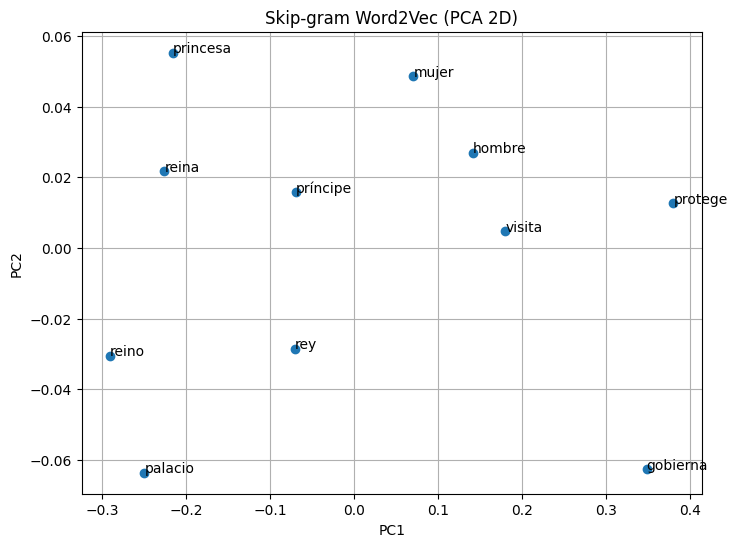

In [14]:
def plot_embeddings_pca(
    model_wv,
    words: Sequence[str],
    title: str = "Word2Vec embeddings projected with PCA",
) -> None:
    valid_words = [w for w in words if w in model_wv]
    X = np.array([model_wv[w] for w in valid_words])

    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_2d[:, 0], X_2d[:, 1])

    for i, word in enumerate(valid_words):
        plt.text(X_2d[i, 0], X_2d[i, 1], word, fontsize=10)

    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.show()


words_to_plot = ["rey", "reina", "hombre", "mujer", "príncipe", "princesa", "reino", "palacio", "gobierna", "visita", "protege"]
plot_embeddings_pca(model.wv, words_to_plot, title="Skip-gram Word2Vec (PCA 2D)")


## 10. Explorando hiperparámetros

Un buen ejercicio docente es entrenar varios modelos y comparar resultados.


In [15]:
def train_word2vec(
    sentences: Sequence[Sequence[str]],
    *,
    vector_size: int = 50,
    window: int = 2,
    min_count: int = 1,
    sg: int = 1,
    negative: int = 8,
    epochs: int = 300,
    seed: int = 7,
) -> Word2Vec:
    return Word2Vec(
        sentences=sentences,
        vector_size=vector_size,
        window=window,
        min_count=min_count,
        workers=1,
        sg=sg,
        negative=negative,
        epochs=epochs,
        seed=seed,
    )


model_window_1 = train_word2vec(tokenized, window=1, sg=1)
model_window_3 = train_word2vec(tokenized, window=3, sg=1)


In [16]:
for w in ["rey", "reina"]:
    print(f"\n=== {w} ===")
    print("window=1:", model_window_1.wv.most_similar(w, topn=4))
    print("window=2:", model.wv.most_similar(w, topn=4))
    print("window=3:", model_window_3.wv.most_similar(w, topn=4))



=== rey ===
window=1: [('la', 0.9965606331825256), ('palacio', 0.996039867401123), ('el', 0.9960300326347351), ('reino', 0.9960289597511292)]
window=2: [('la', 0.9967027902603149), ('palacio', 0.9965837597846985), ('reino', 0.9961450695991516), ('el', 0.9960312247276306)]
window=3: [('la', 0.9965797662734985), ('palacio', 0.9961692094802856), ('reina', 0.9960819482803345), ('reino', 0.9960016012191772)]

=== reina ===
window=1: [('el', 0.9980071783065796), ('y', 0.99651700258255), ('en', 0.9962835311889648), ('protege', 0.9962373971939087)]
window=2: [('el', 0.9977512955665588), ('y', 0.9970065355300903), ('en', 0.9967688322067261), ('viven', 0.9966828227043152)]
window=3: [('el', 0.9978761672973633), ('en', 0.9967614412307739), ('y', 0.9965587258338928), ('palacio', 0.9965028762817383)]


### Comentario pedagógico
- Con una ventana pequeña, el modelo tiende a capturar relaciones más **locales**.
- Con una ventana mayor, puede capturar asociaciones más **globales**, pero también mezclar más contexto.
- En corpora pequeños, pequeños cambios de hiperparámetros pueden alterar bastante los vecinos.


## 11. Exportando embeddings

Si quisieras reutilizar los vectores en otro flujo, gensim permite guardarlos fácilmente.


In [17]:
# Guardar el modelo completo
model.save("word2vec_skipgram_demo.model")

# Guardar solo vectores en formato word2vec
model.wv.save_word2vec_format("word2vec_skipgram_demo.vec", binary=False)

print("Files saved: word2vec_skipgram_demo.model, word2vec_skipgram_demo.vec")


Files saved: word2vec_skipgram_demo.model, word2vec_skipgram_demo.vec


## 12. ¿Cómo llevar esto a un corpus real?

En un proyecto más serio, el flujo típico sería:

1. **Recolectar corpus**  
   Noticias, reseñas, documentos, chats, artículos, etc.

2. **Preprocesar**  
   Tokenización, minúsculas, limpieza, lematización opcional, filtrado de ruido.

3. **Entrenar Word2Vec**  
   Ajustando `vector_size`, `window`, `min_count`, `sg`, `negative`, `epochs`.

4. **Evaluar cualitativamente**  
   - vecinos semánticos
   - analogías
   - clusters temáticos

5. **Usar embeddings aguas abajo**  
   - clasificación
   - clustering
   - búsqueda semántica básica
   - features para otros modelos
   - exploración de lenguaje de dominio


## 13. Limitaciones importantes

Word2Vec clásico tiene una limitación central:

> **Cada palabra tiene un solo vector fijo**, sin importar el contexto.

Eso significa que no resuelve bien ambigüedad léxica. Por ejemplo:
- “banco” (entidad financiera)
- “banco” (asiento)

Ambos sentidos comparten el mismo embedding.

Por eso luego surgieron enfoques:
- **FastText** (subpalabras)
- **ELMo**
- **BERT** y transformers contextualizados

Aun así, Word2Vec sigue siendo excelente para enseñar la lógica de los embeddings.


## 14. Resumen final del Jupyter Book

Con este tercer notebook ya tienes el recorrido completo:

1. **Intuición**: el contexto crea significado.  
2. **Construcción a mano**: SGNS y la red neuronal mínima.  
3. **Paquetes usuales**: entrenamiento práctico con gensim.

Esto deja muy bien preparado el terreno para avanzar luego a:
- FastText
- GloVe
- embeddings contextualizados
- transformers


## 15. Ejercicios propuestos

1. Cambia `use_lemma=True` y compara vecinos.  
2. Activa `remove_stop=True` y revisa si mejora o empeora las analogías.  
3. Entrena modelos con `vector_size=20`, `50` y `100`.  
4. Compara `sg=0` vs `sg=1` para varias palabras.  
5. Usa un corpus propio más grande y analiza si las analogías mejoran.  
6. (Reto) Compara Word2Vec con **FastText** usando gensim.
